# Refined PBP With Server Coverage Check

This notebook pulls `prizepicksanalytics.originations_tennis.refined_pbp_with_server` and summarizes unique match coverage by `mode_best_of`.

In [23]:
import sys
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)

# Ensure local project imports resolve when running from notebooks/
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from injestion.core.bq import get_client

In [24]:
from injestion.core.env import load_env
load_env()

import os
os.environ["GOOGLE_CLOUD_PROJECT"] = "prizepicksanalytics"
# If needed, also set your service-account key path:
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/absolute/path/to/key.json"

from google.cloud import bigquery
bq_client = bigquery.Client(project=os.environ["GOOGLE_CLOUD_PROJECT"])

In [25]:
bq_client = get_client()

table_id = "prizepicksanalytics.originations_tennis.refined_pbp_with_server"
query = f"SELECT * FROM `{table_id}`"

df = bq_client.query(query).to_dataframe()

print(f"Rows fetched: {len(df):,}")
print(f"Columns fetched: {len(df.columns)}")
df.head()

Rows fetched: 1,881,615
Columns fetched: 23


,sport_event_id,timeline_not_available,event_id,event_order,type,time,competitor,period_name,period,home_score,away_score,server,result,first_serve_fault,total_sets,mode_best_of,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,match_status,server_competitor_name,server_competitor_id
0,sr:sport_event:58211283,False,672744,7,point,2025-02-28 00:11:35+00:00,home,None,1.0,40,15,home,server_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
1,sr:sport_event:58211283,False,672844,22,point,2025-02-28 00:23:17+00:00,home,None,1.0,30,0,away,receiver_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
2,sr:sport_event:58211283,False,672854,24,point,2025-02-28 00:24:14+00:00,away,None,1.0,30,30,away,server_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
3,sr:sport_event:58211283,False,672887,30,period_score,2025-02-28 00:27:50+00:00,home,None,1.0,2,2,away,receiver_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
4,sr:sport_event:58211283,False,672902,33,point,2025-02-28 00:29:37+00:00,home,None,1.0,30,15,home,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669


In [26]:
# Determine the match-level key column.
match_id_candidates = ["fixture_id", "sport_event_id", "game_id"]
match_id_col = next((c for c in match_id_candidates if c in df.columns), None)

if match_id_col is None:
    raise ValueError(
        "Could not identify match id column. Expected one of: "
        f"{match_id_candidates}. Found columns: {list(df.columns)}"
    )

if "mode_best_of" not in df.columns:
    raise ValueError("Column 'mode_best_of' is missing from the source table.")

print(f"Using match id column: {match_id_col}")

# Useful sanity checks
print("\nmode_best_of value counts (row-level):")
print(df["mode_best_of"].value_counts(dropna=False).sort_index())

# Match-level counts by mode_best_of
matches = (
    df[[match_id_col, "mode_best_of"]]
    .dropna(subset=[match_id_col])
    .drop_duplicates(subset=[match_id_col])
)

summary = (
    matches.groupby("mode_best_of", dropna=False)[match_id_col]
    .nunique()
    .reset_index(name="unique_matches")
    .sort_values("mode_best_of")
)

total_unique_matches = matches[match_id_col].nunique()
summary["pct_of_matches"] = (summary["unique_matches"] / total_unique_matches * 100).round(2)

print("\nUnique match counts by mode_best_of:")
display(summary)

print(f"Total unique matches: {total_unique_matches:,}")

# Focused best-of-3 vs best-of-5 view
bo3_bo5 = summary[summary["mode_best_of"].isin([3, 5])].copy()
print("\nBest-of-3 vs Best-of-5 unique matches:")
display(bo3_bo5)

bo3_count = int(bo3_bo5.loc[bo3_bo5["mode_best_of"] == 3, "unique_matches"].sum())
bo5_count = int(bo3_bo5.loc[bo3_bo5["mode_best_of"] == 5, "unique_matches"].sum())

if bo5_count > 0:
    print(f"Best-of-3 / Best-of-5 ratio: {bo3_count / bo5_count:.2f}x")
else:
    print("Best-of-3 / Best-of-5 ratio: undefined (no best-of-5 matches found)")

Using match id column: sport_event_id

mode_best_of value counts (row-level):
mode_best_of
3    1744694
5     136921
Name: count, dtype: Int64

Unique match counts by mode_best_of:


,mode_best_of,unique_matches,pct_of_matches
0,3,11964,95.3
1,5,590,4.7


Total unique matches: 12,554

Best-of-3 vs Best-of-5 unique matches:


,mode_best_of,unique_matches,pct_of_matches
0,3,11964,95.3
1,5,590,4.7


Best-of-3 / Best-of-5 ratio: 20.28x


In [27]:
df[df.sport_event_id == 'sr:sport_event:58211283'].head(10).sort_values(by='event_order', ascending=True)

,sport_event_id,timeline_not_available,event_id,event_order,type,time,competitor,period_name,period,home_score,away_score,server,result,first_serve_fault,total_sets,mode_best_of,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,match_status,server_competitor_name,server_competitor_id
0,sr:sport_event:58211283,False,672744,7,point,2025-02-28 00:11:35+00:00,home,None,1.0,40,15,home,server_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
1,sr:sport_event:58211283,False,672844,22,point,2025-02-28 00:23:17+00:00,home,None,1.0,30,0,away,receiver_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
2,sr:sport_event:58211283,False,672854,24,point,2025-02-28 00:24:14+00:00,away,None,1.0,30,30,away,server_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
3,sr:sport_event:58211283,False,672887,30,period_score,2025-02-28 00:27:50+00:00,home,None,1.0,2,2,away,receiver_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
4,sr:sport_event:58211283,False,672902,33,point,2025-02-28 00:29:37+00:00,home,None,1.0,30,15,home,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
5,sr:sport_event:58211283,False,672967,43,period_score,2025-02-28 00:37:30+00:00,home,None,1.0,3,3,away,receiver_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
6,sr:sport_event:58211283,False,672983,45,point,2025-02-28 00:39:07+00:00,home,None,1.0,15,15,home,server_won,True,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Tien, Learner",sr:competitor:891669
7,sr:sport_event:58211283,False,673020,52,point,2025-02-28 00:44:26+00:00,away,None,1.0,0,15,away,server_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
8,sr:sport_event:58211283,False,673029,54,point,2025-02-28 00:45:50+00:00,away,None,1.0,15,30,away,server_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540
9,sr:sport_event:58211283,False,673033,55,point,2025-02-28 00:46:22+00:00,away,None,1.0,15,40,away,server_won,<NA>,2,3,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",ended,"Machac, Tomas",sr:competitor:300540


## Data Quality Check 1: Duplicate Events

Audit and remove duplicate events before computing match-level targets.

In [28]:
# Duplicate-event audit and cleanup
# Primary dedupe key: (sport_event_id, event_id)
# This should uniquely identify a timeline event within a match.

required_cols = ["sport_event_id", "event_id"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns for duplicate check: {missing_required}")

rows_before = len(df)

# Focus duplicate check on rows where event_id is present.
df_with_event_id = df[df["event_id"].notna()].copy()
df_without_event_id = df[df["event_id"].isna()].copy()

dup_mask = df_with_event_id.duplicated(subset=["sport_event_id", "event_id"], keep="first")
duplicate_rows = df_with_event_id[dup_mask].copy()
rows_removed = int(dup_mask.sum())

print(f"Total rows before dedupe: {rows_before:,}")
print(f"Rows with non-null event_id: {len(df_with_event_id):,}")
print(f"Rows with null event_id (not deduped by event_id): {len(df_without_event_id):,}")
print(f"Duplicate rows removed (by sport_event_id + event_id): {rows_removed:,}")

if rows_removed > 0:
    affected_fixtures = duplicate_rows["sport_event_id"].nunique()
    print(f"Fixtures affected by duplicates: {affected_fixtures:,}")

    dup_summary = (
        df_with_event_id[df_with_event_id.duplicated(["sport_event_id", "event_id"], keep=False)]
        .groupby(["sport_event_id", "event_id"], as_index=False)
        .size()
        .rename(columns={"size": "duplicate_count"})
        .sort_values(["duplicate_count", "sport_event_id"], ascending=[False, True])
    )

    print("\nTop duplicate event groups:")
    display(dup_summary.head(5))

    print("\nSample duplicate rows for investigation:")
    sample_cols = [
        c for c in [
            "sport_event_id",
            "event_id",
            "event_order",
            "type",
            "time",
            "server",
            "result",
            "home_score",
            "away_score",
        ]
        if c in df.columns
    ]
    display(
        df_with_event_id[df_with_event_id.duplicated(["sport_event_id", "event_id"], keep=False)]
        .sort_values(["sport_event_id", "event_id", "event_order"]) 
        [sample_cols]
        .head(10)
    )
else:
    print("No duplicate events found on (sport_event_id, event_id).")

# Cleaned dataframe for downstream checks
# Keep all null-event_id rows, and dedupe rows with event_id.
df_clean = pd.concat([df_with_event_id[~dup_mask], df_without_event_id], ignore_index=True)

print(f"Total rows after dedupe: {len(df_clean):,}")
print(f"Row delta check (before - after): {rows_before - len(df_clean):,}")

Total rows before dedupe: 1,881,615
Rows with non-null event_id: 1,881,615
Rows with null event_id (not deduped by event_id): 0
Duplicate rows removed (by sport_event_id + event_id): 0
No duplicate events found on (sport_event_id, event_id).
Total rows after dedupe: 1,881,615
Row delta check (before - after): 0


## Build Fixture-Level Point Totals

Aggregate one row per `sport_event_id` and tally total points from rows where `type == "point"`.

In [29]:
# Fixture-level aggregation
# Uses deduped dataframe from prior step when available.

base_df = df_clean.copy() if "df_clean" in globals() else df.copy()

if "sport_event_id" not in base_df.columns:
    raise ValueError("Column 'sport_event_id' is required for fixture-level aggregation.")
if "type" not in base_df.columns:
    raise ValueError("Column 'type' is required to tally point rows.")

# Core point tally
# In this feed, game-clinching points can appear as `period_score`,
# so include both `point` and `period_score` in total point counts.
point_event_types = {"point", "period_score"}

# Game-end interpretation from period_score rows:
# - Holds: server_won OR ace
# - Breaks: receiver_won OR double_fault
point_totals = (
    base_df.assign(
        is_point_event=base_df["type"].isin(point_event_types).astype("int64"),
        is_raw_point=base_df["type"].eq("point").astype("int64"),
        is_period_score=base_df["type"].eq("period_score"),
        is_hold_event=(
            base_df["type"].eq("period_score")
            & base_df["result"].isin(["server_won", "ace"])
        ).astype("int64"),
        is_break_event=(
            base_df["type"].eq("period_score")
            & base_df["result"].isin(["receiver_won", "double_fault"])
        ).astype("int64"),
    )
    .groupby("sport_event_id", as_index=False)
    .agg(
        total_points=("is_point_event", "sum"),
        total_rows_in_pbp=("event_id", "size"),
        point_rows=("is_raw_point", "sum"),
        period_score_rows=("is_period_score", "sum"),
        total_serve_holds=("is_hold_event", "sum"),
        total_serve_breaks=("is_break_event", "sum"),
        first_event_time=("time", "min"),
        last_event_time=("time", "max"),
    )
)

# Fixture-level metadata (first non-null value observed within match)
metadata_cols = [
    "mode_best_of",
    "total_sets",
    "match_status",
    "home_competitor_id",
    "away_competitor_id",
    "home_competitor_name",
    "away_competitor_name",
]
metadata_cols = [c for c in metadata_cols if c in base_df.columns]

def first_non_null(series: pd.Series):
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) else pd.NA

fixture_metadata = (
    base_df.groupby("sport_event_id", as_index=False)[metadata_cols]
    .agg(first_non_null)
    if metadata_cols
    else base_df[["sport_event_id"]].drop_duplicates()
)

fixture_point_totals = point_totals.merge(fixture_metadata, on="sport_event_id", how="left")

print("\nQuick summary of total_points:")
print(fixture_point_totals["total_points"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2))

print("\nSample fixture-level output:")
display(
    fixture_point_totals.sort_values("total_points", ascending=False).head(5)
)

# Keep a canonical ordering for downstream checks
fixture_point_totals = fixture_point_totals.sort_values("sport_event_id").reset_index(drop=True)


Quick summary of total_points:
count    12554.00
mean       143.83
std         44.04
min         56.00
1%          79.00
5%          91.00
50%        133.00
95%        224.00
99%        279.00
max        395.00
Name: total_points, dtype: float64

Sample fixture-level output:


,sport_event_id,total_points,total_rows_in_pbp,point_rows,period_score_rows,total_serve_holds,total_serve_breaks,first_event_time,last_event_time,mode_best_of,total_sets,match_status,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name
7113,sr:sport_event:67664536,395,403,334,61,53,8,2026-01-30 03:45:04+00:00,2026-01-30 09:14:57+00:00,5,5,ended,sr:competitor:407573,sr:competitor:57163,"Alcaraz, Carlos","Zverev, Alexander"
9957,sr:sport_event:71563762,389,397,328,61,54,7,2026-05-30 11:42:09+00:00,2026-05-30 16:56:01+00:00,5,5,ended,sr:competitor:112783,sr:competitor:341192,"Berrettini, Matteo","Comesana, Francisco"
3467,sr:sport_event:61449519,387,396,326,61,55,6,2025-07-05 13:37:58+00:00,2025-07-05 18:46:49+00:00,5,5,ended,sr:competitor:294300,sr:competitor:104847,"Nakashima, Brandon","Sonego, Lorenzo"
2255,sr:sport_event:60690683,385,393,326,59,42,17,2025-06-08 13:27:47+00:00,2025-06-08 18:57:37+00:00,5,5,ended,sr:competitor:225050,sr:competitor:407573,"Sinner, Jannik","Alcaraz, Carlos"
3696,sr:sport_event:61512050,381,389,324,57,53,4,2025-07-01 11:36:08+00:00,2025-07-01 16:07:05+00:00,5,5,ended,sr:competitor:310974,sr:competitor:206879,"De Jong, Jesper","Eubanks, Christopher"


## Merge Final Match Scores And Validate Minimum Points

Pull period-level set scores from `prizepicksanalytics.originations_tennis.sr_event_summaries`, compute fixture-level `total_games_played` and `total_tiebreaks_played`, merge into fixture totals, and validate `total_points >= 4 * total_games_played`.

In [30]:
import ast
import json

# Pull event summaries with period scores
summaries_table_id = "prizepicksanalytics.originations_tennis.sr_event_summaries"
summaries_query = f"""
SELECT
  sport_event_id,
  period_scores,
  competition_type,
  match_status,
  home_score,
  away_score,
  mode_best_of
FROM `{summaries_table_id}`
"""

event_summaries = bq_client.query(summaries_query).to_dataframe()
print(f"Event summary rows fetched: {len(event_summaries):,}")

required_summary_cols = ["sport_event_id", "period_scores"]
missing_summary_cols = [c for c in required_summary_cols if c not in event_summaries.columns]
if missing_summary_cols:
    raise ValueError(f"Missing expected columns in sr_event_summaries: {missing_summary_cols}")


def parse_period_scores(value):
    """Parse period_scores from list/dict/json-string into a python list[dict]."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        # Try JSON first, then Python literal fallback.
        try:
            parsed = json.loads(s)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            try:
                parsed = ast.literal_eval(s)
                return parsed if isinstance(parsed, list) else []
            except Exception:
                return []
    return []


def compute_total_games(period_scores_raw):
    """Sum games across set-level period scores."""
    period_scores = parse_period_scores(period_scores_raw)
    total_games = 0
    for entry in period_scores:
        if not isinstance(entry, dict):
            continue
        if entry.get("type") != "set":
            continue
        h = entry.get("home_score")
        a = entry.get("away_score")
        try:
            if pd.notna(h) and pd.notna(a):
                total_games += int(h) + int(a)
        except Exception:
            continue
    return total_games


def compute_total_tiebreaks(period_scores_raw):
    """Count set-level tiebreaks (7-6 or 6-7) from period scores."""
    period_scores = parse_period_scores(period_scores_raw)
    total_tiebreaks = 0
    for entry in period_scores:
        if not isinstance(entry, dict):
            continue
        if entry.get("type") != "set":
            continue
        h = entry.get("home_score")
        a = entry.get("away_score")
        try:
            if pd.notna(h) and pd.notna(a):
                h_int = int(h)
                a_int = int(a)
                if (h_int == 7 and a_int == 6) or (h_int == 6 and a_int == 7):
                    total_tiebreaks += 1
        except Exception:
            continue
    return total_tiebreaks


summary_games = event_summaries.copy()
summary_games["total_games_played"] = summary_games["period_scores"].apply(compute_total_games)
summary_games["total_tiebreaks_played"] = summary_games["period_scores"].apply(compute_total_tiebreaks)

# Keep one row per fixture id in case table has multiple rows per event.
summary_games_one_row = (
    summary_games.sort_values("sport_event_id")
    .drop_duplicates(subset=["sport_event_id"], keep="first")
    [[
        "sport_event_id",
        "total_games_played",
        "total_tiebreaks_played",
        "competition_type",
        "match_status",
        "home_score",
        "away_score",
        "mode_best_of",
    ]]
    .rename(columns={
        "competition_type": "summary_competition_type",
        "match_status": "summary_match_status",
        "home_score": "summary_home_sets",
        "away_score": "summary_away_sets",
        "mode_best_of": "summary_mode_best_of",
    })
)

# Merge into fixture-level point totals
fixture_point_totals = fixture_point_totals.merge(summary_games_one_row, on="sport_event_id", how="left")

print(f"Fixture rows after merge: {len(fixture_point_totals):,}")
print(
    "Fixtures missing total_games_played after merge: "
    f"{fixture_point_totals['total_games_played'].isna().sum():,}"
)
print(
    "Fixtures missing total_tiebreaks_played after merge: "
    f"{fixture_point_totals['total_tiebreaks_played'].isna().sum():,}"
)

# Restrict scope to singles only.
rows_before_singles_filter = len(fixture_point_totals)
fixture_point_totals = fixture_point_totals[
    fixture_point_totals["summary_competition_type"].astype("string").str.lower() == "singles"
].copy()
print(f"\nSingles-only fixtures kept: {len(fixture_point_totals):,}")
print(f"Rows removed by competition_type filter: {rows_before_singles_filter - len(fixture_point_totals):,}")

# Keep only fixtures where period_score coverage matches derived total games.
validation_df = fixture_point_totals[fixture_point_totals["total_games_played"].notna()].copy()
validation_df["period_score_matches_total_games"] = (
    validation_df["period_score_rows"].astype("int64") == validation_df["total_games_played"].astype("int64")
)

rows_before_period_score_filter = len(validation_df)
validation_df = validation_df[validation_df["period_score_matches_total_games"]].copy()
print(
    "Rows removed by period_score completeness filter: "
    f"{rows_before_period_score_filter - len(validation_df):,}"
)

# Normalize count features by games for stable rate features.
validation_df["break_rate"] = (
    validation_df["total_serve_breaks"] / validation_df["total_games_played"]
)

# Ace rate is added after refined_serve_stats merge if total_aces_match is available.
if "total_aces_match" in validation_df.columns:
    validation_df["ace_rate"] = (
        validation_df["total_aces_match"] / validation_df["total_games_played"]
    )

# Minimum-point validation: total_points must be at least 4 x total_games_played
validation_df["min_possible_points"] = 4 * validation_df["total_games_played"]
validation_df["violates_min_points"] = validation_df["total_points"] < validation_df["min_possible_points"]

violations = validation_df[validation_df["violates_min_points"]].copy()

print("\nMinimum points validation:")
print(f"Fixtures evaluated: {len(validation_df):,}")
print(f"Violations found: {len(violations):,}")

if len(validation_df) > 0:
    violation_rate = len(violations) / len(validation_df) * 100
    print(f"Violation rate: {violation_rate:.2f}%")

if len(violations) > 0:
    cols_to_show = [
        c
        for c in [
            "sport_event_id",
            "total_points",
            "total_games_played",
            "min_possible_points",
            "mode_best_of",
            "summary_mode_best_of",
            "match_status",
            "summary_match_status",
            "summary_competition_type",
            "summary_home_sets",
            "summary_away_sets",
            "home_competitor_name",
            "away_competitor_name",
        ]
        if c in violations.columns
    ]
    print("\nFixtures violating minimum-point rule:")
    display(
        violations[cols_to_show]
        .sort_values(["min_possible_points", "total_points"], ascending=[False, True])
        .head(5)
    )
else:
    print("No fixtures violate total_points >= 4 * total_games_played.")

# Quick sanity distribution view for upcoming outlier exploration
print("\nSanity stats:")
print(
    validation_df[["total_points", "total_games_played", "total_tiebreaks_played", "min_possible_points"]]
    .describe()
    .round(2)
)

# Canonical fixture-level table (singles only) for downstream feature building / upload.
fixture_features = validation_df.copy()

Event summary rows fetched: 34,410
Fixture rows after merge: 12,554
Fixtures missing total_games_played after merge: 0
Fixtures missing total_tiebreaks_played after merge: 0

Singles-only fixtures kept: 9,497
Rows removed by competition_type filter: 3,057
Rows removed by period_score completeness filter: 17

Minimum points validation:
Fixtures evaluated: 9,480
Violations found: 0
Violation rate: 0.00%
No fixtures violate total_points >= 4 * total_games_played.

Sanity stats:
       total_points  total_games_played  total_tiebreaks_played  \
count       9480.00             9480.00                 9480.00   
mean         149.77               23.46                    0.37   
std           46.21                6.96                    0.59   
min           63.00               12.00                    0.00   
25%          114.00               18.00                    0.00   
50%          140.00               22.00                    0.00   
75%          180.00               28.00            

In [31]:
fixture_features.head()

,sport_event_id,total_points,total_rows_in_pbp,point_rows,period_score_rows,total_serve_holds,total_serve_breaks,first_event_time,last_event_time,mode_best_of,total_sets,match_status,home_competitor_id,away_competitor_id,home_competitor_name,away_competitor_name,total_games_played,total_tiebreaks_played,summary_competition_type,summary_match_status,summary_home_sets,summary_away_sets,summary_mode_best_of,period_score_matches_total_games,break_rate,min_possible_points,violates_min_points
0,sr:sport_event:58211283,139,145,118,21,12,9,2025-02-28 00:04:59+00:00,2025-02-28 01:47:32+00:00,3,2,ended,sr:competitor:891669,sr:competitor:300540,"Tien, Learner","Machac, Tomas",21,0,singles,ended,0,2,3,True,0.428571,84,False
1,sr:sport_event:58211287,163,171,136,27,19,8,2025-02-28 02:29:48+00:00,2025-02-28 04:45:46+00:00,3,3,ended,sr:competitor:117916,sr:competitor:42379,"Shapovalov, Denis","Giron, Marcos",27,0,singles,ended,2,1,3,True,0.296296,108,False
2,sr:sport_event:58211289,156,162,135,21,12,9,2025-02-28 00:06:02+00:00,2025-02-28 02:13:11+00:00,3,2,ended,sr:competitor:294300,sr:competitor:25838,"Nakashima, Brandon","Goffin, David",21,1,singles,ended,2,0,3,True,0.428571,84,False
3,sr:sport_event:58211291,162,169,135,27,21,6,2025-03-01 01:04:50+00:00,2025-03-01 03:13:21+00:00,3,3,ended,sr:competitor:300540,sr:competitor:294300,"Machac, Tomas","Nakashima, Brandon",27,0,singles,ended,2,1,3,True,0.222222,108,False
4,sr:sport_event:58211293,94,100,78,16,10,6,2025-02-28 05:02:55+00:00,2025-02-28 06:15:47+00:00,3,2,ended,sr:competitor:157456,sr:competitor:809324,"Davidovich Fokina, Alejandro","Pacheco Mendez, Rodrigo",16,0,singles,ended,2,0,3,True,0.375000,64,False


## Total Points vs Total Games

Scatter plots split by match format (`best of 3` and `best of 5`).

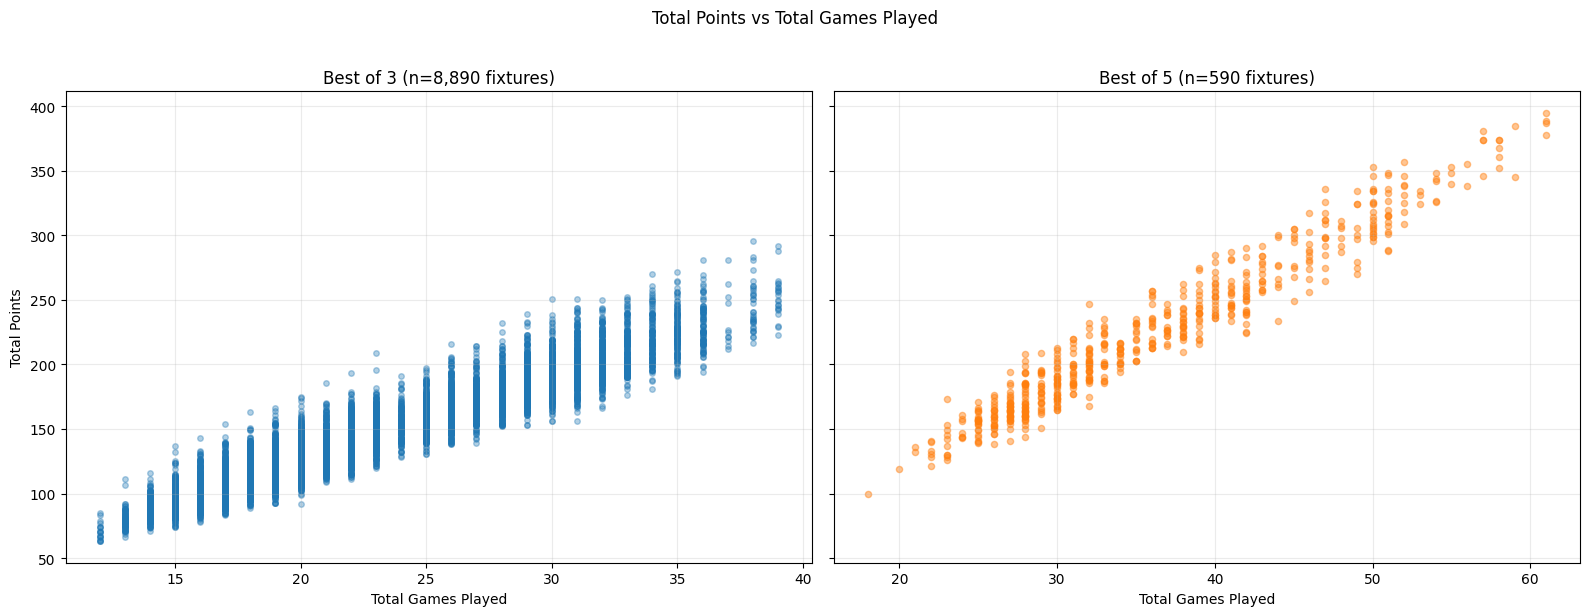

Counts used for plotting:
Best of 3 fixtures: 8,890
Best of 5 fixtures: 590


In [32]:
import matplotlib.pyplot as plt

# Use validated singles data when available.
plot_df = validation_df.copy() if "validation_df" in globals() else fixture_point_totals.copy()

required_plot_cols = ["total_points", "total_games_played"]
missing_plot_cols = [c for c in required_plot_cols if c not in plot_df.columns]
if missing_plot_cols:
    raise ValueError(f"Missing required plotting columns: {missing_plot_cols}")

# Prefer summary mode_best_of from event summaries; fallback to base mode_best_of.
if "summary_mode_best_of" in plot_df.columns:
    plot_df["best_of_for_plot"] = plot_df["summary_mode_best_of"]
elif "mode_best_of" in plot_df.columns:
    plot_df["best_of_for_plot"] = plot_df["mode_best_of"]
else:
    raise ValueError("Could not find best-of column for plotting.")

plot_df = plot_df.dropna(subset=["total_points", "total_games_played", "best_of_for_plot"]).copy()
plot_df["best_of_for_plot"] = pd.to_numeric(plot_df["best_of_for_plot"], errors="coerce")

bo3 = plot_df[plot_df["best_of_for_plot"] == 3]
bo5 = plot_df[plot_df["best_of_for_plot"] == 5]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Best-of-3
axes[0].scatter(
    bo3["total_games_played"],
    bo3["total_points"],
    alpha=0.35,
    s=16,
)
axes[0].set_title(f"Best of 3 (n={len(bo3):,} fixtures)")
axes[0].set_xlabel("Total Games Played")
axes[0].set_ylabel("Total Points")
axes[0].grid(alpha=0.25)

# Best-of-5
axes[1].scatter(
    bo5["total_games_played"],
    bo5["total_points"],
    alpha=0.45,
    s=20,
    color="tab:orange",
)
axes[1].set_title(f"Best of 5 (n={len(bo5):,} fixtures)")
axes[1].set_xlabel("Total Games Played")
axes[1].grid(alpha=0.25)

plt.suptitle("Total Points vs Total Games Played", y=1.02)
plt.tight_layout()
plt.show()

print("Counts used for plotting:")
print(f"Best of 3 fixtures: {len(bo3):,}")
print(f"Best of 5 fixtures: {len(bo5):,}")

## Data Quality Check 2: Period Score Completeness

Compare observed `period_score` event counts against expected total games from final set scores.

In [33]:
# Evaluate whether every completed game has a corresponding period_score event.

check_df = validation_df.copy() if "validation_df" in globals() else fixture_point_totals.copy()

required_cols = ["sport_event_id", "period_score_rows", "total_games_played"]
missing_cols = [c for c in required_cols if c not in check_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for period_score completeness check: {missing_cols}")

check_df = check_df.dropna(subset=["period_score_rows", "total_games_played"]).copy()
check_df["period_score_rows"] = pd.to_numeric(check_df["period_score_rows"], errors="coerce")
check_df["total_games_played"] = pd.to_numeric(check_df["total_games_played"], errors="coerce")
check_df = check_df.dropna(subset=["period_score_rows", "total_games_played"]).copy()

check_df["period_score_matches_total_games"] = (
    check_df["period_score_rows"].astype(int) == check_df["total_games_played"].astype(int)
)
check_df["period_score_game_delta"] = (
    check_df["period_score_rows"].astype(int) - check_df["total_games_played"].astype(int)
)

total_evaluated = len(check_df)
aligned_count = int(check_df["period_score_matches_total_games"].sum())
misaligned_count = total_evaluated - aligned_count
aligned_pct = (aligned_count / total_evaluated * 100) if total_evaluated else 0.0

print("Period-score completeness check:")
print(f"Fixtures evaluated: {total_evaluated:,}")
print(f"Aligned fixtures (period_score_rows == total_games_played): {aligned_count:,}")
print(f"Misaligned fixtures: {misaligned_count:,}")
print(f"Alignment rate: {aligned_pct:.2f}%")

if misaligned_count > 0:
    cols_to_show = [
        c
        for c in [
            "sport_event_id",
            "mode_best_of",
            "summary_mode_best_of",
            "period_score_rows",
            "total_games_played",
            "period_score_game_delta",
            "total_points",
            "summary_home_sets",
            "summary_away_sets",
            "home_competitor_name",
            "away_competitor_name",
            "summary_competition_type",
        ]
        if c in check_df.columns
    ]

    print("\nSample 5 misaligned fixtures:")
    display(
        check_df.loc[~check_df["period_score_matches_total_games"], cols_to_show]
        .sort_values(by="period_score_game_delta", key=lambda s: s.abs(), ascending=False)
        .head(5)
    )
else:
    print("\nNo misaligned fixtures found.")

Period-score completeness check:
Fixtures evaluated: 9,480
Aligned fixtures (period_score_rows == total_games_played): 9,480
Misaligned fixtures: 0
Alignment rate: 100.00%

No misaligned fixtures found.


## Merge Total Aces (Fixture-Level)

Pull player-level totals from `prizepicksanalytics.originations_tennis.refined_serve_stats`, sum `total_aces` across both players per fixture, and merge into the final fixture dataset.

In [34]:
# Pull player-level serve stats and aggregate to fixture-level total aces.
serve_stats_table_id = "prizepicksanalytics.originations_tennis.refined_serve_stats"
serve_stats_query = f"""
SELECT
  sport_event_id,
  competitor_id,
  total_aces
FROM `{serve_stats_table_id}`
"""

serve_stats_df = bq_client.query(serve_stats_query).to_dataframe()
print(f"Serve stats rows fetched: {len(serve_stats_df):,}")

required_ace_cols = ["sport_event_id", "total_aces"]
missing_ace_cols = [c for c in required_ace_cols if c not in serve_stats_df.columns]
if missing_ace_cols:
    raise ValueError(f"Missing expected columns in refined_serve_stats: {missing_ace_cols}")

# Ensure numeric total_aces before aggregation.
serve_stats_df["total_aces"] = pd.to_numeric(serve_stats_df["total_aces"], errors="coerce")

fixture_aces = (
    serve_stats_df.groupby("sport_event_id", as_index=False)
    .agg(
        total_aces_match=("total_aces", "sum"),
        serve_stats_rows=("sport_event_id", "size"),
        non_null_ace_rows=("total_aces", lambda s: int(s.notna().sum())),
    )
)

# Merge into canonical outputs (idempotent: drop prior ace columns first).
ace_cols = ["total_aces_match", "serve_stats_rows", "non_null_ace_rows"]

if "validation_df" in globals():
    validation_df = validation_df.drop(columns=[c for c in ace_cols if c in validation_df.columns], errors="ignore")
    validation_df = validation_df.merge(fixture_aces, on="sport_event_id", how="left")
    validation_df["ace_rate"] = validation_df["total_aces_match"] / validation_df["total_games_played"]

if "fixture_features" in globals():
    fixture_features = fixture_features.drop(columns=[c for c in ace_cols if c in fixture_features.columns], errors="ignore")
    fixture_features = fixture_features.merge(fixture_aces, on="sport_event_id", how="left")
    fixture_features["ace_rate"] = fixture_features["total_aces_match"] / fixture_features["total_games_played"]

print(f"Fixture rows in fixture_features: {len(fixture_features):,}")
print(
    "Fixtures missing total_aces_match: "
    f"{fixture_features['total_aces_match'].isna().sum():,}"
)

print("\nSample fixture-level aces columns:")
sample_cols = [
    c
    for c in [
        "sport_event_id",
        "total_aces_match",
        "serve_stats_rows",
        "non_null_ace_rows",
        "total_points",
        "total_games_played",
        "total_tiebreaks_played",
        "total_serve_holds",
        "total_serve_breaks",
    ]
    if c in fixture_features.columns
]
display(fixture_features[sample_cols].head(10))

Serve stats rows fetched: 25,108
Fixture rows in fixture_features: 9,480
Fixtures missing total_aces_match: 0

Sample fixture-level aces columns:


,sport_event_id,total_aces_match,serve_stats_rows,non_null_ace_rows,total_points,total_games_played,total_tiebreaks_played,total_serve_holds,total_serve_breaks
0,sr:sport_event:58211283,4.0,2,2,139,21,0,12,9
1,sr:sport_event:58211287,5.0,2,2,163,27,0,19,8
2,sr:sport_event:58211289,13.0,2,2,156,21,1,12,9
3,sr:sport_event:58211291,11.0,2,2,162,27,0,21,6
4,sr:sport_event:58211293,4.0,2,2,94,16,0,10,6
5,sr:sport_event:58211295,15.0,2,2,132,21,1,18,3
6,sr:sport_event:58211297,2.0,2,2,175,26,2,18,8
7,sr:sport_event:58211463,15.0,2,2,190,31,0,25,6
8,sr:sport_event:58211465,13.0,2,2,115,20,0,18,2
9,sr:sport_event:58211467,8.0,2,2,118,18,0,15,3


## First-Pass Residual Model Comparison (Bo3 vs Bo5)

Train simple Gaussian, Poisson, and Negative Binomial regressions on residual points (`total_points - 4 * total_games_played`) and compare holdout error by match format.

In [35]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, PoissonRegressor, TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ModuleNotFoundError:
    HAS_STATSMODELS = False

# Canonical modeling frame
model_df = fixture_features.copy()

# Residual target above theoretical floor
model_df["min_points_floor"] = 4 * model_df["total_games_played"]
model_df["residual_points"] = model_df["total_points"] - model_df["min_points_floor"]

feature_cols = [
    "total_games_played",
    "break_rate",
    "ace_rate",
    "total_tiebreaks_played",
]

required_cols = feature_cols + ["residual_points", "total_points", "summary_mode_best_of"]
missing_cols = [c for c in required_cols if c not in model_df.columns]
if missing_cols:
    raise ValueError(f"Missing required modeling columns: {missing_cols}")

model_df = model_df.dropna(subset=required_cols).copy()
model_df["summary_mode_best_of"] = pd.to_numeric(model_df["summary_mode_best_of"], errors="coerce")
model_df = model_df.dropna(subset=["summary_mode_best_of"]).copy()
model_df["summary_mode_best_of"] = model_df["summary_mode_best_of"].astype(int)

# Guard for count target assumptions
model_df = model_df[model_df["residual_points"] >= 0].copy()
model_df["residual_points"] = model_df["residual_points"].astype(int)


def evaluate_segment(df_seg: pd.DataFrame, segment_label: str) -> pd.DataFrame:
    X = df_seg[feature_cols].copy()
    y_resid = df_seg["residual_points"].astype(float)
    floor = df_seg["min_points_floor"].astype(float)
    y_total = df_seg["total_points"].astype(float)

    X_train, X_test, y_train, y_test, floor_train, floor_test, y_total_train, y_total_test = train_test_split(
        X,
        y_resid,
        floor,
        y_total,
        test_size=0.2,
        random_state=42,
    )

    rows = []

    # 1) Gaussian (OLS-style)
    gauss = LinearRegression()
    gauss.fit(X_train, y_train)
    mu_resid_gauss = np.clip(gauss.predict(X_test), 0, None)
    pred_total_gauss = floor_test + mu_resid_gauss
    rows.append(
        {
            "segment": segment_label,
            "model": "GaussianLinear",
            "n_train": len(X_train),
            "n_test": len(X_test),
            "mae_total_points": mean_absolute_error(y_total_test, pred_total_gauss),
            "rmse_total_points": np.sqrt(mean_squared_error(y_total_test, pred_total_gauss)),
        }
    )

    # 2) Poisson regression
    pois = PoissonRegressor(alpha=0.0, max_iter=2000)
    pois.fit(X_train, y_train)
    mu_resid_pois = np.clip(pois.predict(X_test), 0, None)
    pred_total_pois = floor_test + mu_resid_pois
    rows.append(
        {
            "segment": segment_label,
            "model": "Poisson",
            "n_train": len(X_train),
            "n_test": len(X_test),
            "mae_total_points": mean_absolute_error(y_total_test, pred_total_pois),
            "rmse_total_points": np.sqrt(mean_squared_error(y_total_test, pred_total_pois)),
        }
    )

    # 3) Overdispersed count model
    if HAS_STATSMODELS:
        # Negative Binomial regression (estimates dispersion from data)
        X_train_sm = sm.add_constant(X_train, has_constant="add")
        X_test_sm = sm.add_constant(X_test, has_constant="add")
        nb = sm.NegativeBinomial(y_train, X_train_sm)
        nb_res = nb.fit(disp=False)
        mu_resid_od = np.clip(nb_res.predict(X_test_sm), 0, None)
        model_name = "NegativeBinomial"
    else:
        # Fallback when statsmodels is unavailable: Tweedie with 1<power<2
        # behaves like an overdispersed Poisson-style GLM for positive counts.
        tw = TweedieRegressor(power=1.5, alpha=0.0, link="log", max_iter=2000)
        tw.fit(X_train, y_train)
        mu_resid_od = np.clip(tw.predict(X_test), 0, None)
        model_name = "TweedieOverdispersed"

    pred_total_od = floor_test + mu_resid_od
    rows.append(
        {
            "segment": segment_label,
            "model": model_name,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "mae_total_points": mean_absolute_error(y_total_test, pred_total_od),
            "rmse_total_points": np.sqrt(mean_squared_error(y_total_test, pred_total_od)),
        }
    )

    return pd.DataFrame(rows)


results_bo3 = evaluate_segment(model_df[model_df["summary_mode_best_of"] == 3], "best_of_3")
results_bo5 = evaluate_segment(model_df[model_df["summary_mode_best_of"] == 5], "best_of_5")

model_comparison = pd.concat([results_bo3, results_bo5], ignore_index=True)
model_comparison = model_comparison.sort_values(["segment", "mae_total_points", "rmse_total_points"]).reset_index(drop=True)

display(model_comparison.round(4))

,segment,model,n_train,n_test,mae_total_points,rmse_total_points
0,best_of_3,GaussianLinear,7112,1778,9.5395,12.0978
1,best_of_3,Poisson,7112,1778,9.6912,12.2751
2,best_of_3,TweedieOverdispersed,7112,1778,9.6914,12.2839
3,best_of_5,GaussianLinear,472,118,9.9712,13.1052
4,best_of_5,TweedieOverdispersed,472,118,10.6309,13.6594
5,best_of_5,Poisson,472,118,10.7236,13.7694


## Gaussian Coefficients (Impact Check)

Refit Gaussian linear models by segment and inspect raw + standardized coefficients to assess feature impact.

In [36]:
from sklearn.linear_model import LinearRegression

# Build modeling frame if not already present
coef_df = model_df.copy() if "model_df" in globals() else fixture_features.copy()

if "residual_points" not in coef_df.columns:
    coef_df["min_points_floor"] = 4 * coef_df["total_games_played"]
    coef_df["residual_points"] = coef_df["total_points"] - coef_df["min_points_floor"]

coef_features = [
    "total_games_played",
    "break_rate",
    "ace_rate",
    "total_tiebreaks_played",
]

required = coef_features + ["residual_points", "summary_mode_best_of"]
missing = [c for c in required if c not in coef_df.columns]
if missing:
    raise ValueError(f"Missing required columns for coefficient analysis: {missing}")

coef_df = coef_df.dropna(subset=required).copy()
coef_df["summary_mode_best_of"] = pd.to_numeric(coef_df["summary_mode_best_of"], errors="coerce")
coef_df = coef_df.dropna(subset=["summary_mode_best_of"]).copy()
coef_df["summary_mode_best_of"] = coef_df["summary_mode_best_of"].astype(int)


def fit_and_summarize_gaussian(segment_df: pd.DataFrame, segment_label: str) -> pd.DataFrame:
    X = segment_df[coef_features].astype(float)
    y = segment_df["residual_points"].astype(float)

    model = LinearRegression()
    model.fit(X, y)

    raw_rows = pd.DataFrame(
        {
            "segment": segment_label,
            "feature": coef_features,
            "coef_raw": model.coef_,
            "feature_mean": X.mean().values,
            "feature_std": X.std(ddof=0).values,
        }
    )

    # Standardized impact: change in prediction from +1 feature std.
    raw_rows["coef_per_1sd"] = raw_rows["coef_raw"] * raw_rows["feature_std"]
    raw_rows["abs_coef_per_1sd"] = raw_rows["coef_per_1sd"].abs()

    intercept_row = pd.DataFrame(
        {
            "segment": [segment_label],
            "feature": ["intercept"],
            "coef_raw": [model.intercept_],
            "feature_mean": [np.nan],
            "feature_std": [np.nan],
            "coef_per_1sd": [np.nan],
            "abs_coef_per_1sd": [np.nan],
        }
    )

    out = pd.concat([intercept_row, raw_rows], ignore_index=True)
    return out


coef_bo3 = fit_and_summarize_gaussian(coef_df[coef_df["summary_mode_best_of"] == 3], "best_of_3")
coef_bo5 = fit_and_summarize_gaussian(coef_df[coef_df["summary_mode_best_of"] == 5], "best_of_5")
coef_table = pd.concat([coef_bo3, coef_bo5], ignore_index=True)

# Display raw coefficients first, then standardized impact ranking per segment.
print("Raw coefficients (target = residual_points):")
display(coef_table[["segment", "feature", "coef_raw"]].round(4))

impact_table = (
    coef_table[coef_table["feature"] != "intercept"]
    .sort_values(["segment", "abs_coef_per_1sd"], ascending=[True, False])
    [["segment", "feature", "coef_per_1sd", "abs_coef_per_1sd"]]
)
print("\nStandardized impact ranking (+1 SD feature change):")
display(impact_table.round(4))

Raw coefficients (target = residual_points):


,segment,feature,coef_raw
0,best_of_3,intercept,-6.9356
1,best_of_3,total_games_played,2.4566
2,best_of_3,break_rate,23.2705
3,best_of_3,ace_rate,-5.9769
4,best_of_3,total_tiebreaks_played,4.1022
5,best_of_5,intercept,-5.3741
6,best_of_5,total_games_played,2.2536
7,best_of_5,break_rate,39.7002
8,best_of_5,ace_rate,-13.1896
9,best_of_5,total_tiebreaks_played,5.1845



Standardized impact ranking (+1 SD feature change):


,segment,feature,coef_per_1sd,abs_coef_per_1sd
1,best_of_3,total_games_played,14.4757,14.4757
2,best_of_3,break_rate,3.0040,3.0040
4,best_of_3,total_tiebreaks_played,2.3459,2.3459
3,best_of_3,ace_rate,-1.5062,1.5062
6,best_of_5,total_games_played,20.6248,20.6248
9,best_of_5,total_tiebreaks_played,4.1214,4.1214
7,best_of_5,break_rate,3.0838,3.0838
8,best_of_5,ace_rate,-2.8692,2.8692


## Ablation: Residual Models Without `total_games_played`

Evaluate residual prediction using only `break_rate`, `ace_rate`, and `total_tiebreaks_played` (separately for best-of-3 and best-of-5).

In [37]:
from sklearn.linear_model import LinearRegression, PoissonRegressor, TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Rebuild modeling frame if needed
ablation_df = model_df.copy() if "model_df" in globals() else fixture_features.copy()
if "residual_points" not in ablation_df.columns:
    ablation_df["min_points_floor"] = 4 * ablation_df["total_games_played"]
    ablation_df["residual_points"] = ablation_df["total_points"] - ablation_df["min_points_floor"]

feature_cols_no_games = ["break_rate", "ace_rate", "total_tiebreaks_played"]
required_cols = feature_cols_no_games + ["residual_points", "summary_mode_best_of"]
missing_cols = [c for c in required_cols if c not in ablation_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for no-games ablation: {missing_cols}")

ablation_df = ablation_df.dropna(subset=required_cols).copy()
ablation_df["summary_mode_best_of"] = pd.to_numeric(ablation_df["summary_mode_best_of"], errors="coerce")
ablation_df = ablation_df.dropna(subset=["summary_mode_best_of"]).copy()
ablation_df["summary_mode_best_of"] = ablation_df["summary_mode_best_of"].astype(int)
ablation_df = ablation_df[ablation_df["residual_points"] >= 0].copy()


def eval_no_games_segment(df_seg: pd.DataFrame, segment_label: str) -> pd.DataFrame:
    X = df_seg[feature_cols_no_games].astype(float)
    y = df_seg["residual_points"].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    rows = []

    # Gaussian linear
    gl = LinearRegression()
    gl.fit(X_train, y_train)
    pred_gl = np.clip(gl.predict(X_test), 0, None)
    rows.append(
        {
            "segment": segment_label,
            "model": "GaussianLinear_no_games",
            "n_train": len(X_train),
            "n_test": len(X_test),
            "mae_residual": mean_absolute_error(y_test, pred_gl),
            "rmse_residual": np.sqrt(mean_squared_error(y_test, pred_gl)),
        }
    )

    # Poisson
    pois = PoissonRegressor(alpha=0.0, max_iter=2000)
    pois.fit(X_train, y_train)
    pred_pois = np.clip(pois.predict(X_test), 0, None)
    rows.append(
        {
            "segment": segment_label,
            "model": "Poisson_no_games",
            "n_train": len(X_train),
            "n_test": len(X_test),
            "mae_residual": mean_absolute_error(y_test, pred_pois),
            "rmse_residual": np.sqrt(mean_squared_error(y_test, pred_pois)),
        }
    )

    # Overdispersed count model
    if "HAS_STATSMODELS" in globals() and HAS_STATSMODELS:
        X_train_sm = sm.add_constant(X_train, has_constant="add")
        X_test_sm = sm.add_constant(X_test, has_constant="add")
        nb = sm.NegativeBinomial(y_train, X_train_sm)
        nb_res = nb.fit(disp=False)
        pred_od = np.clip(nb_res.predict(X_test_sm), 0, None)
        model_name = "NegativeBinomial_no_games"
    else:
        tw = TweedieRegressor(power=1.5, alpha=0.0, link="log", max_iter=2000)
        tw.fit(X_train, y_train)
        pred_od = np.clip(tw.predict(X_test), 0, None)
        model_name = "TweedieOverdispersed_no_games"

    rows.append(
        {
            "segment": segment_label,
            "model": model_name,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "mae_residual": mean_absolute_error(y_test, pred_od),
            "rmse_residual": np.sqrt(mean_squared_error(y_test, pred_od)),
        }
    )

    # Gaussian coefficients for interpretation
    coef_tbl = pd.DataFrame(
        {
            "segment": segment_label,
            "feature": feature_cols_no_games,
            "coef_raw": gl.coef_,
            "feature_std": X.std(ddof=0).values,
        }
    )
    coef_tbl["coef_per_1sd"] = coef_tbl["coef_raw"] * coef_tbl["feature_std"]
    intercept_tbl = pd.DataFrame(
        {
            "segment": [segment_label],
            "feature": ["intercept"],
            "coef_raw": [gl.intercept_],
            "feature_std": [np.nan],
            "coef_per_1sd": [np.nan],
        }
    )
    coef_out = pd.concat([intercept_tbl, coef_tbl], ignore_index=True)

    return pd.DataFrame(rows), coef_out


perf_bo3, coef_bo3 = eval_no_games_segment(
    ablation_df[ablation_df["summary_mode_best_of"] == 3], "best_of_3"
)
perf_bo5, coef_bo5 = eval_no_games_segment(
    ablation_df[ablation_df["summary_mode_best_of"] == 5], "best_of_5"
)

no_games_performance = (
    pd.concat([perf_bo3, perf_bo5], ignore_index=True)
    .sort_values(["segment", "mae_residual", "rmse_residual"])
    .reset_index(drop=True)
)
no_games_coefficients = pd.concat([coef_bo3, coef_bo5], ignore_index=True)

# Minimal outputs
print("Residual prediction performance (without total_games_played):")
display(no_games_performance.round(4))

print("\nGaussian coefficients (without total_games_played):")
display(no_games_coefficients[["segment", "feature", "coef_raw", "coef_per_1sd"]].round(4))

Residual prediction performance (without total_games_played):


,segment,model,n_train,n_test,mae_residual,rmse_residual
0,best_of_3,Poisson_no_games,7112,1778,13.7335,17.2503
1,best_of_3,TweedieOverdispersed_no_games,7112,1778,13.7367,17.2531
2,best_of_3,GaussianLinear_no_games,7112,1778,13.7666,17.2700
3,best_of_5,GaussianLinear_no_games,472,118,17.2696,21.1697
4,best_of_5,Poisson_no_games,472,118,17.5665,21.3453
5,best_of_5,TweedieOverdispersed_no_games,472,118,17.5797,21.3538



Gaussian coefficients (without total_games_played):


,segment,feature,coef_raw,coef_per_1sd
0,best_of_3,intercept,49.8620,NaN
1,best_of_3,break_rate,6.3425,0.8188
2,best_of_3,ace_rate,-9.2765,-2.3378
3,best_of_3,total_tiebreaks_played,17.4278,9.9665
4,best_of_5,intercept,81.7234,NaN
5,best_of_5,break_rate,0.5372,0.0417
6,best_of_5,ace_rate,-25.5161,-5.5507
7,best_of_5,total_tiebreaks_played,19.4794,15.4850


## Bo5 Feature Stability Check (L2 + Bootstrap)

Assess whether `break_rate` is stable enough to keep in the bo5 residual model.

What to watch:
- L2 path: does `break_rate` coefficient quickly shrink to ~0 with little/no loss in error?
- Bootstrap: does `break_rate` keep a consistent sign and reasonably tight interval?

In [38]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Use the same residual target setup as prior sections.
stability_df = model_df.copy() if "model_df" in globals() else fixture_features.copy()
if "residual_points" not in stability_df.columns:
    stability_df["min_points_floor"] = 4 * stability_df["total_games_played"]
    stability_df["residual_points"] = stability_df["total_points"] - stability_df["min_points_floor"]

feature_cols_bo5 = [
    "total_games_played",
    "break_rate",
    "ace_rate",
    "total_tiebreaks_played",
]

required_cols = feature_cols_bo5 + ["residual_points", "summary_mode_best_of"]
missing_cols = [c for c in required_cols if c not in stability_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for bo5 stability check: {missing_cols}")

stability_df = stability_df.dropna(subset=required_cols).copy()
stability_df["summary_mode_best_of"] = pd.to_numeric(stability_df["summary_mode_best_of"], errors="coerce")
stability_df = stability_df.dropna(subset=["summary_mode_best_of"]).copy()
stability_df["summary_mode_best_of"] = stability_df["summary_mode_best_of"].astype(int)

bo5_df = stability_df[(stability_df["summary_mode_best_of"] == 5) & (stability_df["residual_points"] >= 0)].copy()

X = bo5_df[feature_cols_bo5].astype(float)
y = bo5_df["residual_points"].astype(float)

# --- 1) L2 regularization path ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alpha_grid = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.5, 5.0, 10.0, 25.0, 50.0]
l2_rows = []

for alpha in alpha_grid:
    if alpha == 0.0:
        model = LinearRegression()
        model_name = "OLS"
    else:
        model = Ridge(alpha=alpha)
        model_name = "Ridge"

    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, None)

    coef_map = dict(zip(feature_cols_bo5, model.coef_))
    l2_rows.append(
        {
            "model": model_name,
            "alpha": alpha,
            "mae_residual": mean_absolute_error(y_test, pred),
            "rmse_residual": np.sqrt(mean_squared_error(y_test, pred)),
            "coef_total_games": coef_map["total_games_played"],
            "coef_break_rate": coef_map["break_rate"],
            "coef_ace_rate": coef_map["ace_rate"],
            "coef_tiebreaks": coef_map["total_tiebreaks_played"],
        }
    )

l2_table = pd.DataFrame(l2_rows).sort_values("alpha").reset_index(drop=True)

# --- 2) Bootstrap coefficient stability (OLS) ---
B = 500
rng = np.random.default_rng(42)

coef_samples = {f: [] for f in feature_cols_bo5}

X_np = X.values
y_np = y.values
n = len(X_np)

for _ in range(B):
    idx = rng.integers(0, n, size=n)
    X_b = X_np[idx]
    y_b = y_np[idx]

    m = LinearRegression()
    m.fit(X_b, y_b)

    for j, f in enumerate(feature_cols_bo5):
        coef_samples[f].append(float(m.coef_[j]))

boot_rows = []
for f in feature_cols_bo5:
    arr = np.array(coef_samples[f], dtype=float)
    boot_rows.append(
        {
            "feature": f,
            "coef_mean": arr.mean(),
            "coef_std": arr.std(ddof=0),
            "coef_p05": np.percentile(arr, 5),
            "coef_p50": np.percentile(arr, 50),
            "coef_p95": np.percentile(arr, 95),
            "pct_positive": (arr > 0).mean() * 100,
            "pct_negative": (arr < 0).mean() * 100,
        }
    )

bootstrap_table = pd.DataFrame(boot_rows)

# Minimal output
print("Bo5 L2 regularization path (residual prediction + coefficients):")
display(l2_table.round(4))

print("\nBo5 bootstrap coefficient stability (OLS, 500 resamples):")
display(bootstrap_table.round(4))

Bo5 L2 regularization path (residual prediction + coefficients):


,model,alpha,mae_residual,rmse_residual,coef_total_games,coef_break_rate,coef_ace_rate,coef_tiebreaks
0,OLS,0.00,9.9712,13.1052,2.2338,35.5622,-16.3756,4.7018
1,Ridge,0.05,9.9724,13.1094,2.2329,34.7693,-16.4472,4.6843
2,Ridge,0.10,9.9735,13.1135,2.2321,34.0137,-16.5133,4.6676
3,Ridge,0.25,9.9759,13.1253,2.2299,31.9455,-16.6827,4.6207
4,Ridge,0.50,9.9781,13.1432,2.2268,29.0426,-16.8862,4.5521
5,Ridge,1.00,9.9875,13.1719,2.2225,24.6677,-17.0904,4.4402
6,Ridge,2.50,9.9961,13.2179,2.2166,17.2875,-16.9387,4.2097
7,Ridge,5.00,10.0172,13.2373,2.2149,11.8718,-15.9490,3.9642
8,Ridge,10.00,10.0519,13.2334,2.2179,7.5941,-13.8171,3.6435
9,Ridge,25.00,10.1125,13.2357,2.2305,3.8746,-9.5779,3.0909



Bo5 bootstrap coefficient stability (OLS, 500 resamples):


,feature,coef_mean,coef_std,coef_p05,coef_p50,coef_p95,pct_positive,pct_negative
0,total_games_played,2.2511,0.0798,2.1157,2.2532,2.3825,100.0,0.0
1,break_rate,39.4001,8.6144,26.1826,38.9684,54.0096,100.0,0.0
2,ace_rate,-13.3196,2.7886,-18.0448,-13.2512,-8.9000,0.0,100.0
3,total_tiebreaks_played,5.2134,0.9576,3.6373,5.1842,6.8565,100.0,0.0


## Secondary Gaussian Models (Missing-Consensus Scenarios)

Evaluate Gaussian linear models across 8 feature availability scenarios for best-of-3 and best-of-5.

Uses 5 bootstrap resamples with out-of-bag evaluation and reports MAE/RMSE on total points.

In [39]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

scenario_df = fixture_features.copy()
scenario_df["summary_mode_best_of"] = pd.to_numeric(
    scenario_df["summary_mode_best_of"], errors="coerce"
)

feature_scenarios = [
    ("1_games_only", ["total_games_played"]),
    ("2_games_aces", ["total_games_played", "total_aces_match"]),
    ("3_games_break_rate", ["total_games_played", "break_rate"]),
    ("4_games_tiebreaks", ["total_games_played", "total_tiebreaks_played"]),
    ("5_games_aces_break", ["total_games_played", "total_aces_match", "break_rate"]),
    ("6_games_aces_tiebreaks", ["total_games_played", "total_aces_match", "total_tiebreaks_played"]),
    ("7_games_break_tiebreaks", ["total_games_played", "break_rate", "total_tiebreaks_played"]),
    (
        "8_all_four",
        ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"],
    ),
]


def bootstrap_eval_linear(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "total_points",
    n_bootstrap: int = 5,
    seed: int = 42,
) -> dict:
    work = df.dropna(subset=feature_cols + [target_col]).copy()
    n = len(work)
    if n < 20:
        return {
            "n_obs": n,
            "n_boot_used": 0,
            "mae_mean": np.nan,
            "mae_std": np.nan,
            "rmse_mean": np.nan,
            "rmse_std": np.nan,
        }

    X = work[feature_cols].to_numpy(dtype=float)
    y = work[target_col].to_numpy(dtype=float)

    rng = np.random.default_rng(seed)
    maes: list[float] = []
    rmses: list[float] = []

    for _ in range(n_bootstrap):
        train_idx = rng.integers(0, n, size=n)
        in_bag = np.zeros(n, dtype=bool)
        in_bag[train_idx] = True
        test_idx = np.where(~in_bag)[0]  # out-of-bag evaluation

        if len(test_idx) == 0:
            continue

        model = LinearRegression()
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])

        maes.append(mean_absolute_error(y[test_idx], pred))
        rmses.append(np.sqrt(mean_squared_error(y[test_idx], pred)))

    if len(maes) == 0:
        return {
            "n_obs": n,
            "n_boot_used": 0,
            "mae_mean": np.nan,
            "mae_std": np.nan,
            "rmse_mean": np.nan,
            "rmse_std": np.nan,
        }

    return {
        "n_obs": n,
        "n_boot_used": len(maes),
        "mae_mean": float(np.mean(maes)),
        "mae_std": float(np.std(maes, ddof=0)),
        "rmse_mean": float(np.mean(rmses)),
        "rmse_std": float(np.std(rmses, ddof=0)),
    }


rows = []
for segment_label, bo in [("best_of_3", 3), ("best_of_5", 5)]:
    seg_df = scenario_df[scenario_df["summary_mode_best_of"] == bo].copy()

    for scenario_name, cols in feature_scenarios:
        metrics = bootstrap_eval_linear(
            seg_df,
            feature_cols=cols,
            target_col="total_points",
            n_bootstrap=5,
            seed=42,
        )
        rows.append(
            {
                "segment": segment_label,
                "scenario": scenario_name,
                "features": ", ".join(cols),
                **metrics,
            }
        )

secondary_model_results = pd.DataFrame(rows)
secondary_model_results = secondary_model_results.sort_values(
    ["segment", "mae_mean", "rmse_mean"]
).reset_index(drop=True)

display(secondary_model_results.round(4))

,segment,scenario,features,n_obs,n_boot_used,mae_mean,mae_std,rmse_mean,rmse_std
0,best_of_3,8_all_four,"total_games_played, total_aces_match, break_ra...",8890,5,9.4558,0.0820,12.0531,0.1065
1,best_of_3,7_games_break_tiebreaks,"total_games_played, break_rate, total_tiebreak...",8890,5,9.5588,0.0839,12.1816,0.0873
2,best_of_3,5_games_aces_break,"total_games_played, total_aces_match, break_rate",8890,5,9.5780,0.0858,12.2322,0.1072
3,best_of_3,6_games_aces_tiebreaks,"total_games_played, total_aces_match, total_ti...",8890,5,9.5911,0.1009,12.2412,0.1342
4,best_of_3,3_games_break_rate,"total_games_played, break_rate",8890,5,9.6411,0.0778,12.3187,0.0880
5,best_of_3,2_games_aces,"total_games_played, total_aces_match",8890,5,9.6957,0.1066,12.3964,0.1353
6,best_of_3,4_games_tiebreaks,"total_games_played, total_tiebreaks_played",8890,5,9.9449,0.1033,12.7145,0.1020
7,best_of_3,1_games_only,total_games_played,8890,5,9.9861,0.0982,12.7739,0.1035
8,best_of_5,8_all_four,"total_games_played, total_aces_match, break_ra...",590,5,10.3073,0.3213,13.1164,0.4672
9,best_of_5,7_games_break_tiebreaks,"total_games_played, break_rate, total_tiebreak...",590,5,10.4999,0.3036,13.3651,0.4263


## Calibration Plots (Best vs Worst Scenarios)

Generate two calibration diagnostics for Gaussian models across best/worst feature scenarios in bo3 and bo5:

1. By `total_games_played`: fraction of matches where `actual > predicted_mean` (target ~0.5).
2. By p-more level (5% steps): empirical exceedance at model-implied p-more lines (target: empirical ~= theoretical).

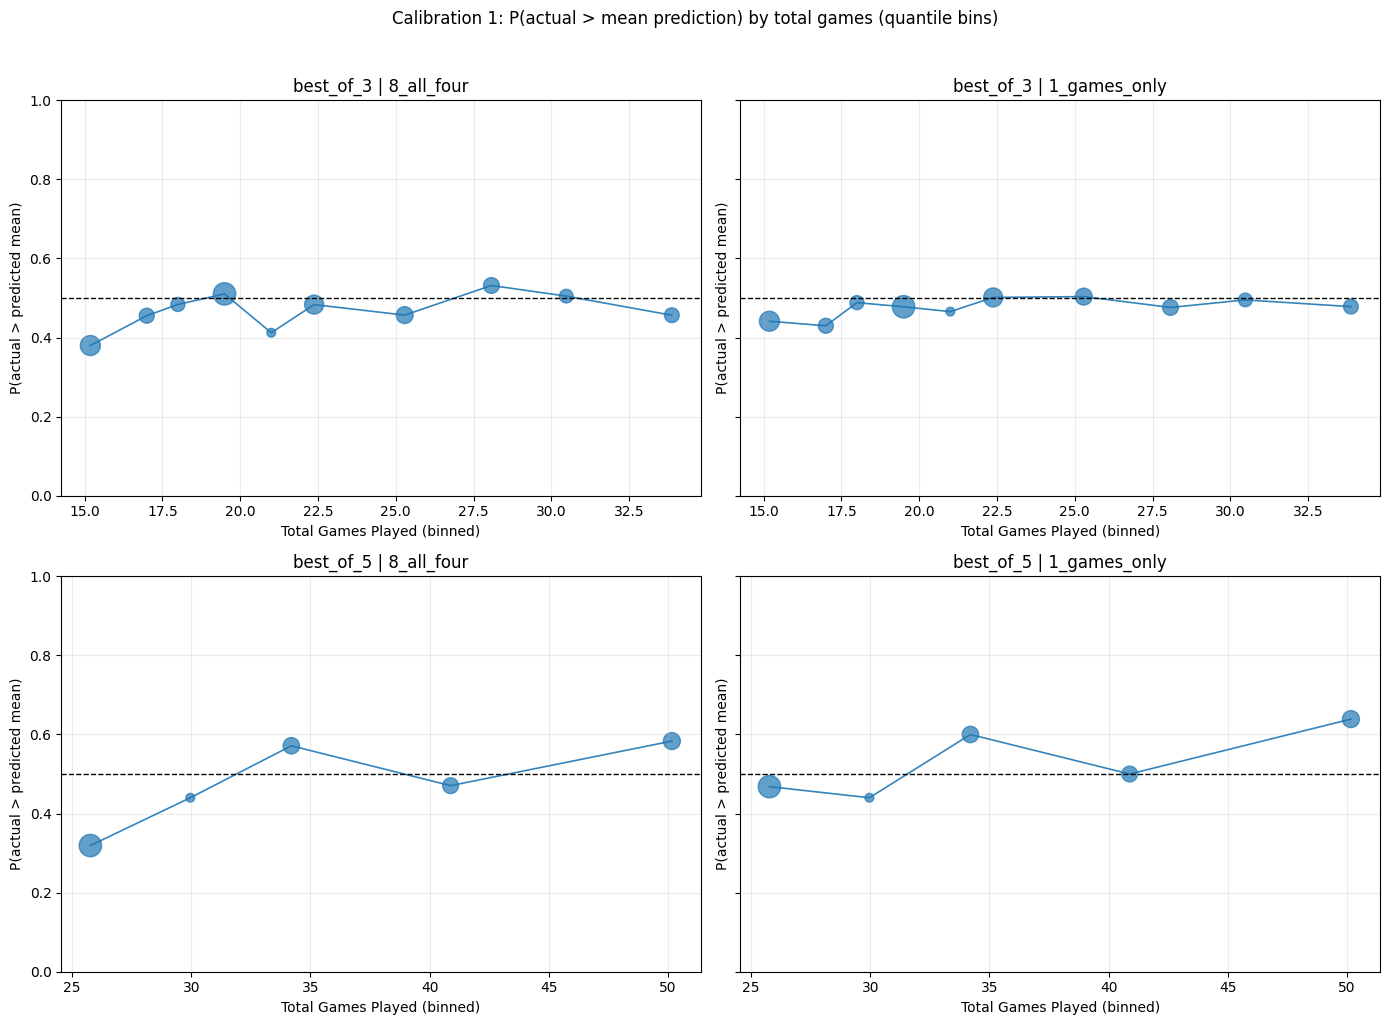

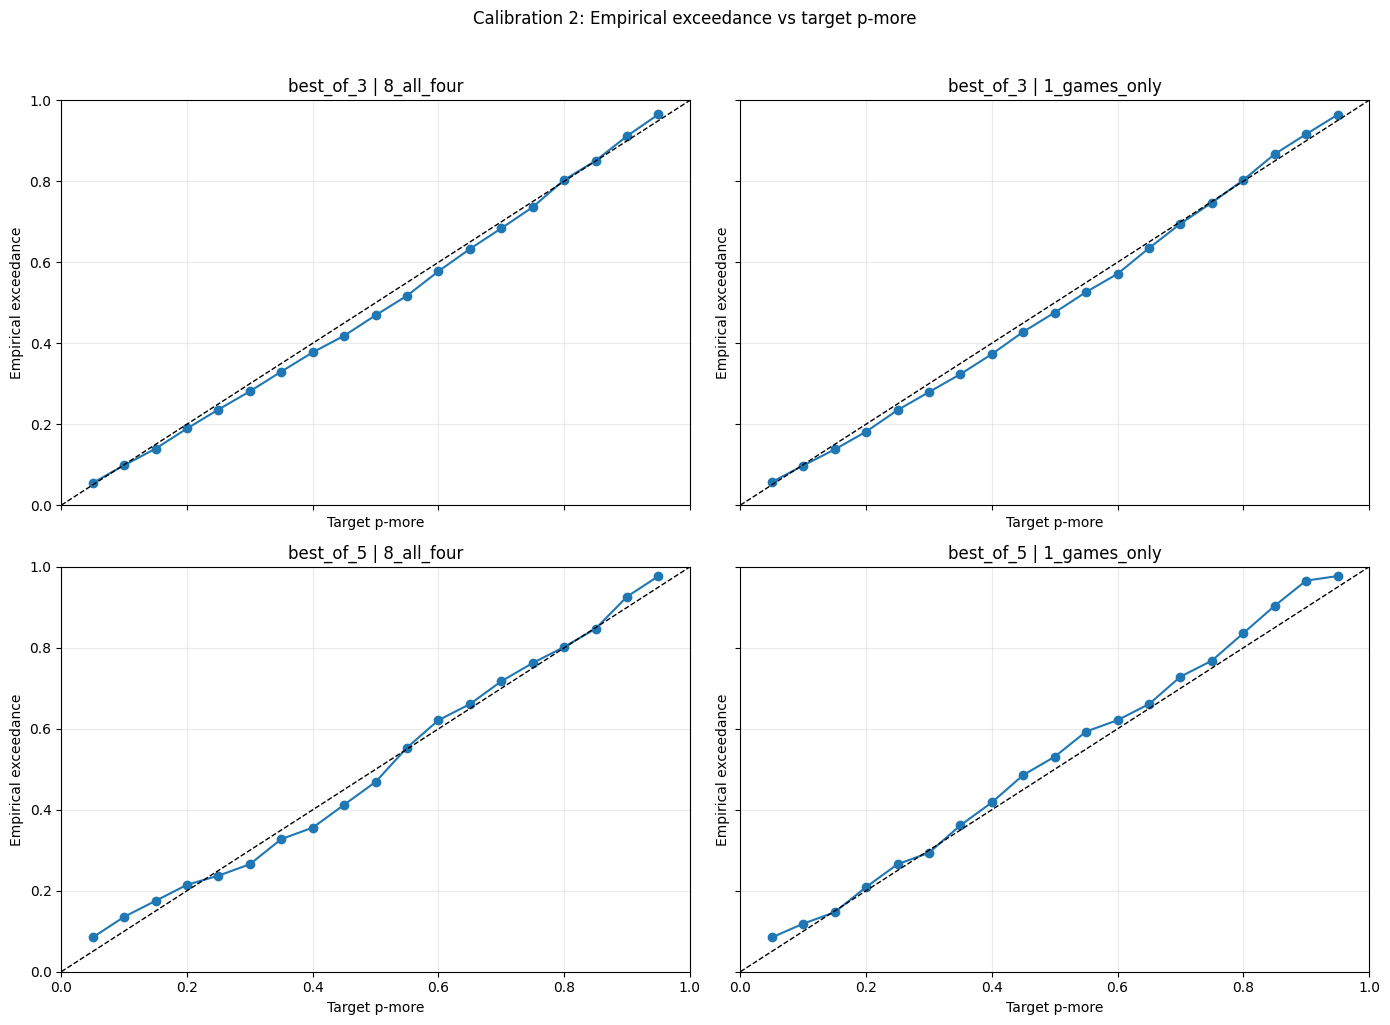

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statistics import NormalDist

cal_df = fixture_features.copy()
cal_df["summary_mode_best_of"] = pd.to_numeric(cal_df["summary_mode_best_of"], errors="coerce")

scenario_map = {
    "best": {
        "scenario": "8_all_four",
        "features": ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"],
    },
    "worst": {
        "scenario": "1_games_only",
        "features": ["total_games_played"],
    },
}

p_more_grid = np.arange(0.05, 1.00, 0.05)
normal = NormalDist(mu=0.0, sigma=1.0)


def fit_gaussian_and_predict(df_seg: pd.DataFrame, features: list[str]):
    work = df_seg.dropna(subset=features + ["total_points", "total_games_played"]).copy()
    X = work[features].to_numpy(dtype=float)
    y = work["total_points"].to_numpy(dtype=float)
    games = work["total_games_played"].to_numpy(dtype=float)

    X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
        X, y, games, test_size=0.3, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    mu_train = model.predict(X_train)
    mu_test = model.predict(X_test)

    # Global sigma per model from train residuals (Gaussian assumption)
    train_resid = y_train - mu_train
    sigma = float(np.std(train_resid, ddof=1))
    sigma = max(sigma, 1e-6)

    out = pd.DataFrame(
        {
            "total_games_played": g_test,
            "actual_points": y_test,
            "pred_mean": mu_test,
            "sigma": sigma,
        }
    )
    return out


# Collect calibration data for each segment/scenario pair
calibration_payload = {}
for segment_label, bo in [("best_of_3", 3), ("best_of_5", 5)]:
    seg = cal_df[cal_df["summary_mode_best_of"] == bo].copy()

    for tier, cfg in scenario_map.items():
        pred_df = fit_gaussian_and_predict(seg, cfg["features"])
        calibration_payload[(segment_label, tier)] = {
            "scenario": cfg["scenario"],
            "features": cfg["features"],
            "pred_df": pred_df,
        }


# --- Plot 1: By games (binned), % actual > predicted mean ---
def bin_by_min_count(
    df: pd.DataFrame,
    game_col: str,
    value_col: str,
    min_count: int = 100,
) -> pd.DataFrame:
    """Create contiguous game bins with at least min_count rows."""
    agg = (
        df.groupby(game_col, as_index=False)
        .agg(n=(value_col, "size"), sum_val=(value_col, "sum"))
        .sort_values(game_col)
        .reset_index(drop=True)
    )

    bins = []
    cur_n = 0
    cur_sum = 0.0
    cur_start = None
    cur_end = None

    for _, row in agg.iterrows():
        g = row[game_col]
        n = int(row["n"])
        s = float(row["sum_val"])

        if cur_start is None:
            cur_start = g
        cur_end = g
        cur_n += n
        cur_sum += s

        if cur_n >= min_count:
            bins.append({"g_start": cur_start, "g_end": cur_end, "n": cur_n, "sum_val": cur_sum})
            cur_n, cur_sum, cur_start, cur_end = 0, 0.0, None, None

    # Handle tail remainder by merging into the previous bin when possible.
    if cur_n > 0:
        if bins:
            bins[-1]["g_end"] = cur_end
            bins[-1]["n"] += cur_n
            bins[-1]["sum_val"] += cur_sum
        else:
            bins.append({"g_start": cur_start, "g_end": cur_end, "n": cur_n, "sum_val": cur_sum})

    binned = pd.DataFrame(bins)
    binned["pct_above_mean"] = binned["sum_val"] / binned["n"]
    binned["games_mid"] = (binned["g_start"] + binned["g_end"]) / 2.0
    return binned


def bin_by_quantiles(
    df: pd.DataFrame,
    game_col: str,
    value_col: str,
    n_bins: int,
) -> pd.DataFrame:
    """Bin by quantiles on total_games_played and aggregate calibration rate per bin."""
    work = df[[game_col, value_col]].dropna().copy()
    work["game_bin"] = pd.qcut(work[game_col], q=n_bins, duplicates="drop")

    binned = (
        work.groupby("game_bin", observed=True)
        .agg(
            n=(value_col, "size"),
            pct_above_mean=(value_col, "mean"),
            g_start=(game_col, "min"),
            g_end=(game_col, "max"),
            games_mid=(game_col, "mean"),
        )
        .reset_index(drop=True)
        .sort_values("games_mid")
    )
    return binned


fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
fig1.suptitle("Calibration 1: P(actual > mean prediction) by total games (quantile bins)", y=1.02)

for idx, ((segment_label, tier), payload) in enumerate(calibration_payload.items()):
    ax = axes1[idx // 2, idx % 2]
    d = payload["pred_df"].copy()

    d["is_above_mean"] = (d["actual_points"] > d["pred_mean"]).astype(float)
    n_bins = 10 if segment_label == "best_of_3" else 5
    by_games = bin_by_quantiles(
        d,
        game_col="total_games_played",
        value_col="is_above_mean",
        n_bins=n_bins,
    )

    # Marker size reflects number of fixtures in each bin.
    n_vals = by_games["n"].to_numpy(dtype=float)
    if len(n_vals) > 0 and np.nanmax(n_vals) > np.nanmin(n_vals):
        sizes = 40 + 220 * ((n_vals - np.nanmin(n_vals)) / (np.nanmax(n_vals) - np.nanmin(n_vals)))
    else:
        sizes = np.full(len(by_games), 120.0)

    ax.plot(by_games["games_mid"], by_games["pct_above_mean"], linewidth=1.2, alpha=0.9)
    ax.scatter(by_games["games_mid"], by_games["pct_above_mean"], s=sizes, alpha=0.7)

    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Total Games Played (binned)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(f"{segment_label} | {payload['scenario']}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# --- Plot 2: p-more calibration curve ---
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
fig2.suptitle("Calibration 2: Empirical exceedance vs target p-more", y=1.02)

for idx, ((segment_label, tier), payload) in enumerate(calibration_payload.items()):
    ax = axes2[idx // 2, idx % 2]
    d = payload["pred_df"].copy()
    sigma = float(d["sigma"].iloc[0])

    empirical = []
    for p_more in p_more_grid:
        # For Gaussian: threshold t where P(Y > t) = p_more
        z = normal.inv_cdf(1.0 - p_more)
        threshold = d["pred_mean"] + sigma * z
        empirical_exceed = (d["actual_points"] > threshold).mean()
        empirical.append(empirical_exceed)

    ax.plot(p_more_grid, empirical, marker="o", linewidth=1.5, label="Empirical")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black", label="Ideal")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Target p-more")
    ax.set_ylabel("Empirical exceedance")
    ax.set_title(f"{segment_label} | {payload['scenario']}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Bootstrap Calibration (Repeated 70/30 Resampling)

Refactored calibration plots using repeated random 70/30 splits.

For each repeat:
- retrain Gaussian model,
- evaluate on that repeat's 30% test split,
- aggregate calibration curves.

Plots show median curve with 10–90% uncertainty bands.

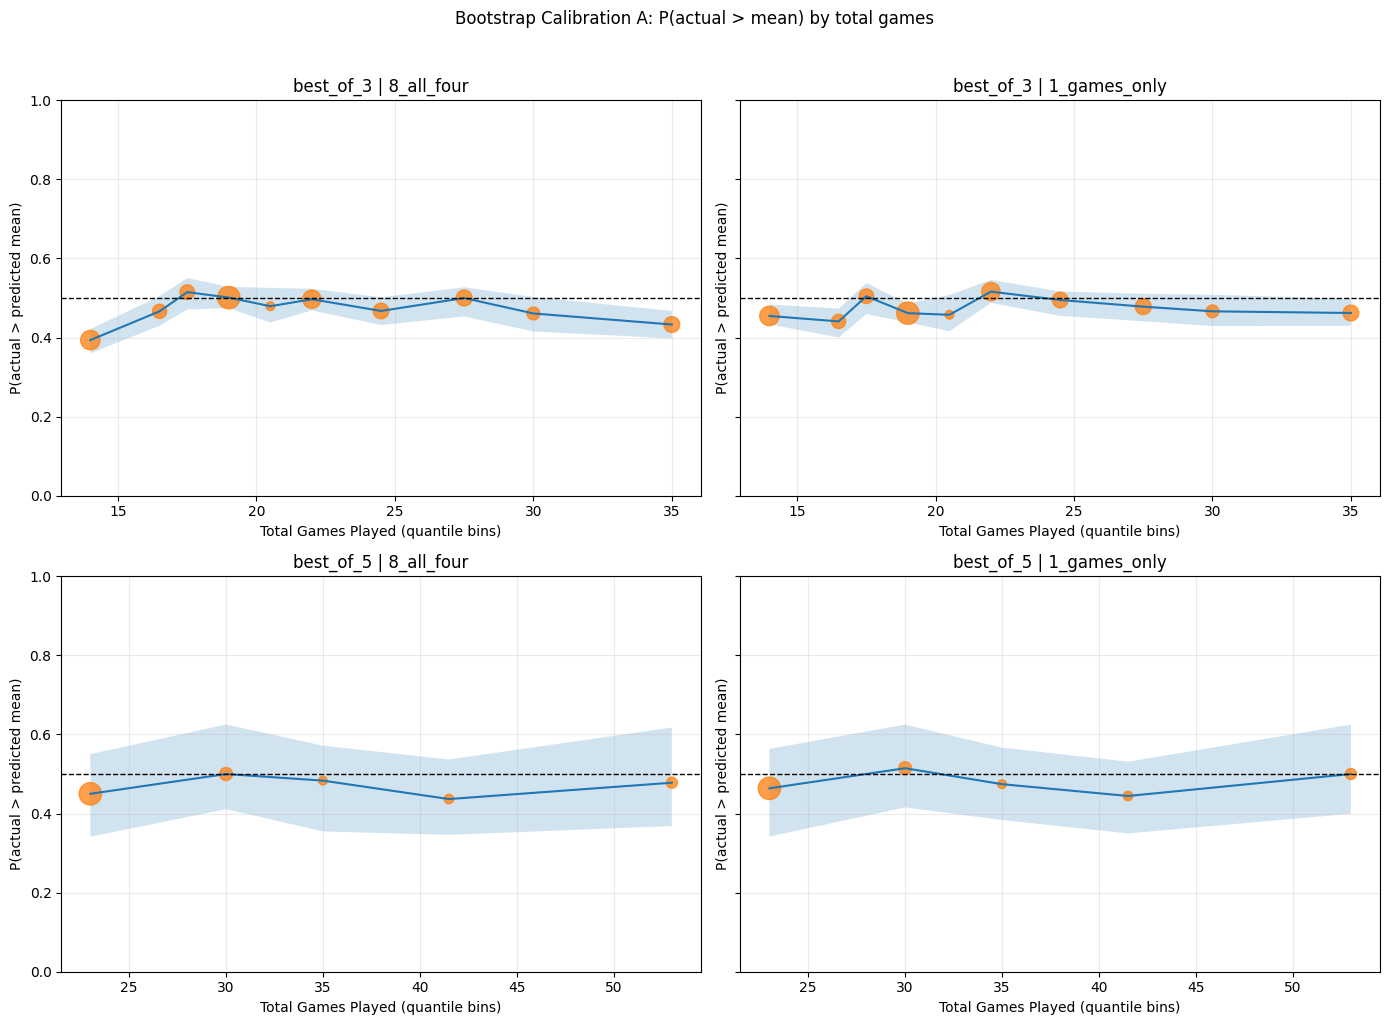

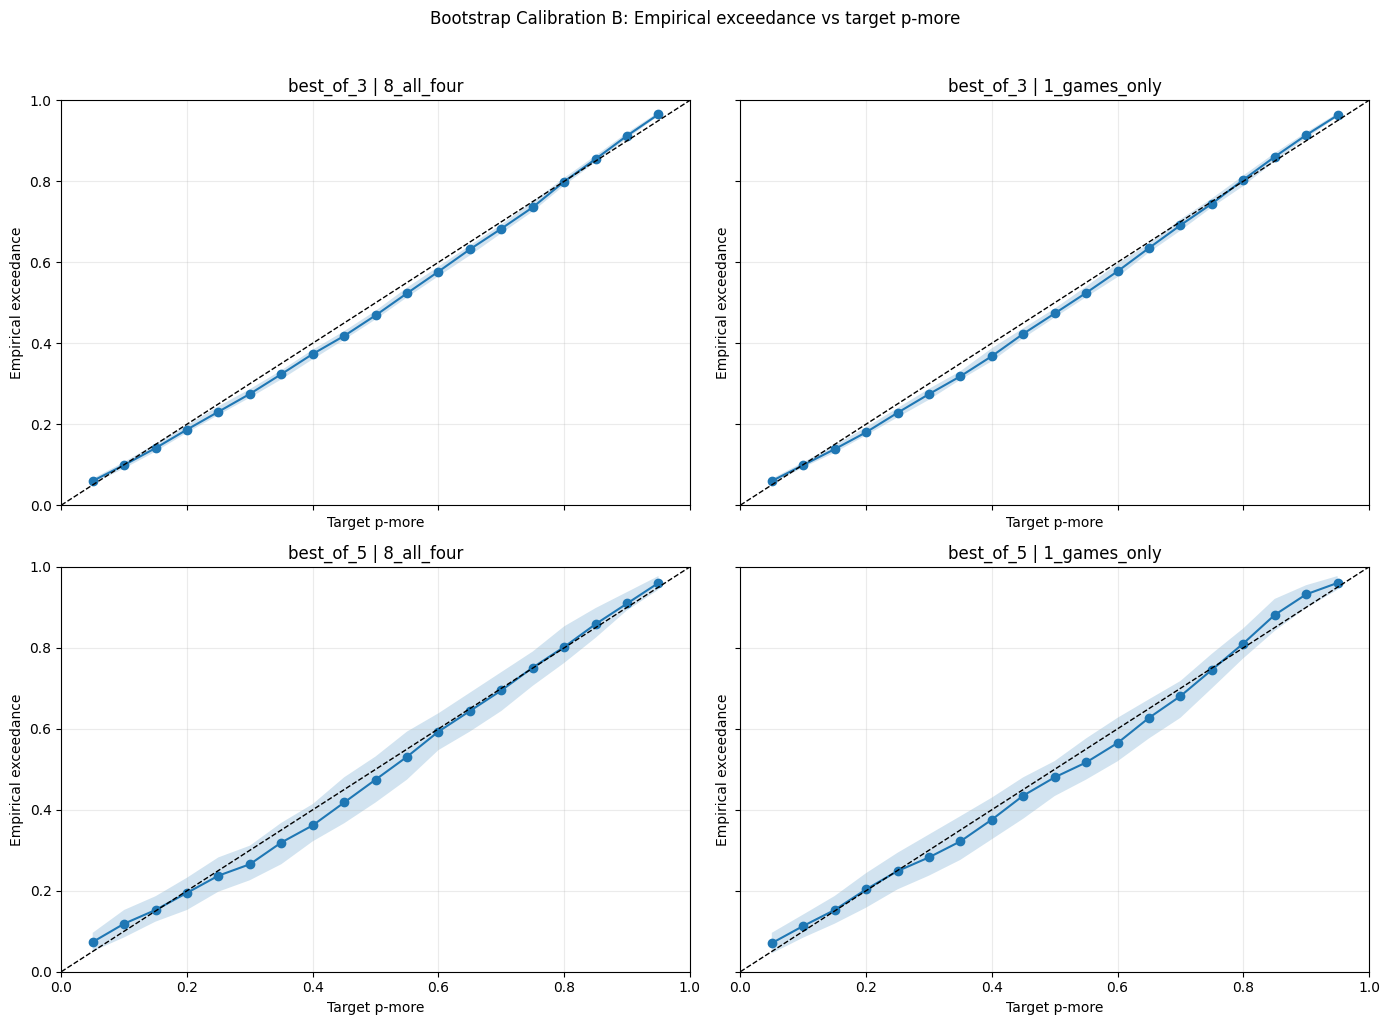

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statistics import NormalDist

# Settings
N_REPEATS = 100
TEST_SIZE = 0.30
P_MORE_GRID = np.arange(0.05, 1.00, 0.05)
normal = NormalDist(mu=0.0, sigma=1.0)

boot_df = fixture_features.copy()
boot_df["summary_mode_best_of"] = pd.to_numeric(boot_df["summary_mode_best_of"], errors="coerce")

scenario_map = {
    "best": {
        "scenario": "8_all_four",
        "features": ["total_games_played", "total_aces_match", "break_rate", "total_tiebreaks_played"],
    },
    "worst": {
        "scenario": "1_games_only",
        "features": ["total_games_played"],
    },
}


def quantile_edges(series: pd.Series, n_bins: int) -> np.ndarray:
    """Fixed bin edges from full data; robust to duplicate quantiles."""
    vals = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    if len(vals) == 0:
        return np.array([0.0, 1.0])

    probs = np.linspace(0.0, 1.0, n_bins + 1)
    edges = np.quantile(vals, probs)
    edges = np.unique(edges)

    if len(edges) < 2:
        v = float(vals[0])
        edges = np.array([v - 0.5, v + 0.5])

    return edges


def summarize_curve(samples_2d: np.ndarray) -> dict:
    """Return median and central band across repeats (axis=0)."""
    return {
        "p10": np.nanpercentile(samples_2d, 10, axis=0),
        "p50": np.nanpercentile(samples_2d, 50, axis=0),
        "p90": np.nanpercentile(samples_2d, 90, axis=0),
    }


def run_repeated_calibration(df_seg: pd.DataFrame, features: list[str], n_bins: int, n_repeats: int):
    """Repeated 70/30 split calibration outputs for two plot types."""
    needed = features + ["total_points", "total_games_played"]
    data = df_seg.dropna(subset=needed).copy()

    X = data[features].to_numpy(dtype=float)
    y = data["total_points"].to_numpy(dtype=float)
    g = data["total_games_played"].to_numpy(dtype=float)

    # Fixed game bins from full segment/scenario data for cross-repeat comparability
    edges = quantile_edges(data["total_games_played"], n_bins=n_bins)
    n_effective_bins = len(edges) - 1
    bin_mids = (edges[:-1] + edges[1:]) / 2.0

    curve1_samples = []   # shape: [repeat, bins]
    curve1_counts = []    # shape: [repeat, bins]
    curve2_samples = []   # shape: [repeat, len(P_MORE_GRID)]

    for r in range(n_repeats):
        X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
            X, y, g, test_size=TEST_SIZE, random_state=10_000 + r
        )

        model = LinearRegression()
        model.fit(X_train, y_train)

        mu_train = model.predict(X_train)
        mu_test = model.predict(X_test)

        sigma = float(np.std(y_train - mu_train, ddof=1))
        sigma = max(sigma, 1e-6)

        # Curve 1: P(actual > mean) by fixed game bins
        test_df = pd.DataFrame(
            {
                "games": g_test,
                "actual": y_test,
                "pred_mean": mu_test,
            }
        )
        test_df["is_above_mean"] = (test_df["actual"] > test_df["pred_mean"]).astype(float)
        test_df["bin_id"] = pd.cut(test_df["games"], bins=edges, include_lowest=True, labels=False)

        by_bin = (
            test_df.groupby("bin_id", dropna=False)["is_above_mean"]
            .agg(["mean", "size"])
            .rename(columns={"mean": "pct", "size": "n"})
        )

        curve_vals = np.full(n_effective_bins, np.nan)
        count_vals = np.zeros(n_effective_bins)

        for b in range(n_effective_bins):
            if b in by_bin.index and pd.notna(by_bin.loc[b, "pct"]):
                curve_vals[b] = float(by_bin.loc[b, "pct"])
                count_vals[b] = float(by_bin.loc[b, "n"])

        curve1_samples.append(curve_vals)
        curve1_counts.append(count_vals)

        # Curve 2: empirical exceedance by p-more level
        exceed_vals = []
        for p_more in P_MORE_GRID:
            z = normal.inv_cdf(1.0 - p_more)
            threshold = mu_test + sigma * z
            exceed_vals.append(float((y_test > threshold).mean()))

        curve2_samples.append(np.array(exceed_vals, dtype=float))

    curve1_arr = np.vstack(curve1_samples)
    count_arr = np.vstack(curve1_counts)
    curve2_arr = np.vstack(curve2_samples)

    return {
        "bin_mids": bin_mids,
        "curve1": summarize_curve(curve1_arr),
        "curve1_mean_count": np.nanmean(count_arr, axis=0),
        "curve2": summarize_curve(curve2_arr),
    }


# Build payloads for 4 panels (bo3/bo5 x best/worst)
boot_payload = {}
for segment_label, bo in [("best_of_3", 3), ("best_of_5", 5)]:
    seg = boot_df[boot_df["summary_mode_best_of"] == bo].copy()
    n_bins = 10 if bo == 3 else 5

    for tier, cfg in scenario_map.items():
        boot_payload[(segment_label, tier)] = {
            "scenario": cfg["scenario"],
            "result": run_repeated_calibration(
                df_seg=seg,
                features=cfg["features"],
                n_bins=n_bins,
                n_repeats=N_REPEATS,
            ),
        }


# --- Plot A: P(actual > mean) by games bin with bootstrap bands ---
figA, axesA = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
figA.suptitle("Bootstrap Calibration A: P(actual > mean) by total games", y=1.02)

for idx, ((segment_label, tier), payload) in enumerate(boot_payload.items()):
    ax = axesA[idx // 2, idx % 2]
    res = payload["result"]

    x = res["bin_mids"]
    y50 = res["curve1"]["p50"]
    y10 = res["curve1"]["p10"]
    y90 = res["curve1"]["p90"]

    n_vals = res["curve1_mean_count"]
    if len(n_vals) > 0 and np.nanmax(n_vals) > np.nanmin(n_vals):
        sizes = 40 + 220 * ((n_vals - np.nanmin(n_vals)) / (np.nanmax(n_vals) - np.nanmin(n_vals)))
    else:
        sizes = np.full(len(x), 120.0)

    ax.fill_between(x, y10, y90, alpha=0.2)
    ax.plot(x, y50, linewidth=1.5)
    ax.scatter(x, y50, s=sizes, alpha=0.75)

    ax.axhline(0.5, linestyle="--", linewidth=1, color="black")
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Total Games Played (quantile bins)")
    ax.set_ylabel("P(actual > predicted mean)")
    ax.set_title(f"{segment_label} | {payload['scenario']}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# --- Plot B: p-more empirical exceedance with bootstrap bands ---
figB, axesB = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
figB.suptitle("Bootstrap Calibration B: Empirical exceedance vs target p-more", y=1.02)

for idx, ((segment_label, tier), payload) in enumerate(boot_payload.items()):
    ax = axesB[idx // 2, idx % 2]
    res = payload["result"]

    y50 = res["curve2"]["p50"]
    y10 = res["curve2"]["p10"]
    y90 = res["curve2"]["p90"]

    ax.fill_between(P_MORE_GRID, y10, y90, alpha=0.2)
    ax.plot(P_MORE_GRID, y50, marker="o", linewidth=1.5)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Target p-more")
    ax.set_ylabel("Empirical exceedance")
    ax.set_title(f"{segment_label} | {payload['scenario']}")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Upload Refined Fixture Stats

Write the finalized fixture-level dataset to BigQuery as `refined_fixture_stats`.

In [42]:
from injestion.core.bq import get_client
from refined_tables import get_table_id, replace_table
from refined_tables.schema import fixture_stats as schema_fixture_stats

client = get_client()

if "fixture_features" not in globals():
    raise ValueError("fixture_features is not defined. Run the feature-building cells first.")

upload_df = fixture_features.copy()

# Canonical schema column order and presence.
schema_fields = schema_fixture_stats.get_schema()
schema_cols = [field.name for field in schema_fields]

for col in schema_cols:
    if col not in upload_df.columns:
        upload_df[col] = pd.NA

upload_df = upload_df[schema_cols].copy()

# Coerce types to align with schema before upload.
int_cols = [
    "total_points",
    "total_rows_in_pbp",
    "point_rows",
    "period_score_rows",
    "total_serve_holds",
    "total_serve_breaks",
    "mode_best_of",
    "total_sets",
    "total_games_played",
    "total_tiebreaks_played",
    "summary_home_sets",
    "summary_away_sets",
    "summary_mode_best_of",
    "min_possible_points",
    "serve_stats_rows",
    "non_null_ace_rows",
]
for col in int_cols:
    upload_df[col] = pd.to_numeric(upload_df[col], errors="coerce").astype("Int64")

float_cols = ["break_rate", "total_aces_match", "ace_rate"]
for col in float_cols:
    upload_df[col] = pd.to_numeric(upload_df[col], errors="coerce")

bool_cols = ["period_score_matches_total_games", "violates_min_points"]
for col in bool_cols:
    upload_df[col] = upload_df[col].astype("boolean")

for col in ["first_event_time", "last_event_time"]:
    upload_df[col] = pd.to_datetime(upload_df[col], errors="coerce", utc=True)

# Prefer refined-table config if available; fallback to explicit table id requested.
try:
    destination_table_id = get_table_id("fixture_stats")
except Exception:
    destination_table_id = "prizepicksanalytics.originations_tennis.refined_fixture_stats"

print(f"Uploading {len(upload_df):,} rows to {destination_table_id}")
job = replace_table(
    client,
    destination_table_id,
    upload_df,
    schema=schema_fields,
)
job

Uploading 9,480 rows to prizepicksanalytics.originations_tennis.refined_fixture_stats


/Users/matt.holden/Projects/tennis-origination/.venv/lib/python3.13/site-packages/google/cloud/bigquery/_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


LoadJob<project=prizepicksanalytics, location=US, id=bcc48c42-b8d2-4ed9-9157-05582af73688>